Examining changes in diet and food-web connections for all scenarios and simulations

In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import itertools
import warnings
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups

warnings.simplefilter('ignore')

In [2]:
control = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/control-2039-2042/outputSalishSeaDietCheck.txt",sep=" ")

In [3]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
scenario_paths = sorted([p for p in scenario_root.glob('highres-2039-2042_5b*2019-07-03/outputSalishSeaDietCheck.txt')])
for path in scenario_paths:
    print(path.parent.stem)

highres-2039-2042_5b_1_2019-07-03
highres-2039-2042_5b_2_2019-07-03
highres-2039-2042_5b_3_2019-07-03
highres-2039-2042_5b_4_2019-07-03
highres-2039-2042_5b_5_2019-07-03
highres-2039-2042_5b_6_2019-07-03
highres-2039-2042_5b_7_2019-07-03
highres-2039-2042_5b_8_2019-07-03
highres-2039-2042_5b_9_2019-07-03


In [4]:
control

,Time,Predator,Cohort,Stock,Updated,FHE,FPS,FSA,FCH,FCO,...,PS,ZL,ZM,ZS,PB,BB,BO,DL,DR,DC
0,365.0,FHE,0,0,0,0.0,0.000010,0.000000e+00,0.0,0.0,...,0.683097,9.208459e-03,0.000704,1.098412e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
1,365.0,FHE,1,0,0,0.0,0.000760,0.000000e+00,0.0,0.0,...,0.598297,1.519491e-02,0.001019,1.084551e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
2,365.0,FHE,2,0,0,0.0,0.005336,0.000000e+00,0.0,0.0,...,0.219277,8.257306e-03,0.001103,4.502025e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
3,365.0,FHE,3,0,0,0.0,0.009828,0.000000e+00,0.0,0.0,...,0.216432,8.606171e-03,0.001200,4.542254e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
4,365.0,FHE,4,0,0,0.0,0.011105,0.000000e+00,0.0,0.0,...,0.216520,8.497695e-03,0.001189,4.544038e-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14595,18249.5,ZG,0,0,1,0.0,0.000000,1.642711e-08,0.0,0.0,...,0.000000,0.000000e+00,0.210498,7.329534e-03,0.672439,0.000000,0.000000,0.005831,0.103879,0.000000e+00
14596,18249.5,ZL,0,0,1,0.0,0.000000,0.000000e+00,0.0,0.0,...,0.000000,1.967147e-12,0.810014,1.646050e-02,0.000053,0.000000,0.000000,0.000497,0.000010,4.895094e-23
14597,18249.5,ZM,0,0,1,0.0,0.000000,0.000000e+00,0.0,0.0,...,0.045044,0.000000e+00,0.000900,3.922019e-03,0.010001,0.000000,0.000000,0.000139,0.000000,0.000000e+00
14598,18249.5,ZS,0,0,1,0.0,0.000000,0.000000e+00,0.0,0.0,...,0.982920,0.000000e+00,0.000000,2.127942e-09,0.001975,0.000000,0.000000,0.000762,0.000475,5.382102e-22


Resident orca diet

In [5]:
control_ORR = control[(control['Predator'] == 'ORR')]

In [6]:
control_ORR

,Time,Predator,Cohort,Stock,Updated,FHE,FPS,FSA,FCH,FCO,...,PS,ZL,ZM,ZS,PB,BB,BO,DL,DR,DC
246,365.0,ORR,0,0,0,0.543321,0.126301,0.0,0.015936,0.001930,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
247,365.0,ORR,1,0,0,0.541923,0.126725,0.0,0.015930,0.001935,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
248,365.0,ORR,2,0,0,0.471500,0.111762,0.0,0.013954,0.001709,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
249,365.0,ORR,3,0,0,0.468978,0.112231,0.0,0.013947,0.001717,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
250,365.0,ORR,4,0,0,0.467603,0.112609,0.0,0.013963,0.001721,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14559,18249.5,ORR,5,0,1,0.399697,0.002914,0.0,0.025927,0.004339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14560,18249.5,ORR,6,0,1,0.399705,0.002914,0.0,0.025935,0.004339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14561,18249.5,ORR,7,0,1,0.399669,0.002915,0.0,0.025922,0.004339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14562,18249.5,ORR,8,0,1,0.399687,0.002914,0.0,0.025932,0.004339,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


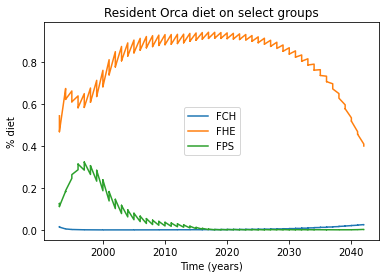

In [8]:
plt.plot(control_ORR.Time/365+1992,control_ORR.FCH, label='FCH') 
plt.plot(control_ORR.Time/365+1992,control_ORR.FHE, label='FHE')
plt.plot(control_ORR.Time/365+1992,control_ORR.FPS,label='FPS')
plt.xlabel('Time (years)')
plt.ylabel('% diet')
plt.title('Resident Orca diet on select groups')
plt.legend();

In [9]:
scenario_datasets = [pd.read_csv(scen, sep=" ") for scen in scenario_paths]

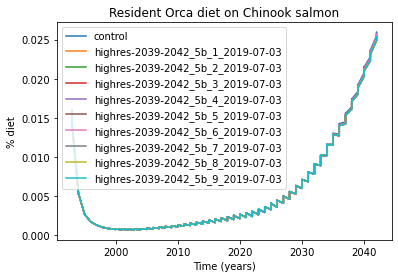

In [10]:
plt.plot(control_ORR.Time/365+1992, control_ORR.FCH, label='control')
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_ORR = scen[(scen['Predator'] == 'ORR')]
    plt.plot(scen_ORR.Time/365+1992, scen_ORR.FCH, label = path.parent.stem)
plt.xlabel('Time (years)')
plt.ylabel('% diet')
plt.title('Resident Orca diet on Chinook salmon')
plt.legend();

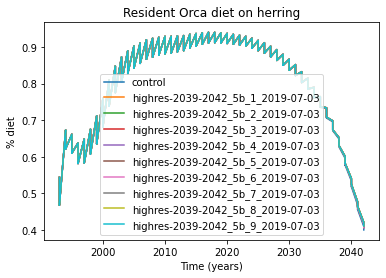

In [11]:
plt.plot(control_ORR.Time/365+1992, control_ORR.FHE, label='control')
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_ORR = scen[(scen['Predator'] == 'ORR')]
    plt.plot(scen_ORR.Time/365+1992, scen_ORR.FHE, label = path.parent.stem)
plt.xlabel('Time (years)')
plt.ylabel('% diet')
plt.title('Resident Orca diet on herring')
plt.legend();

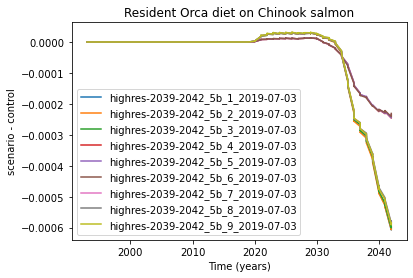

In [17]:
#plt.plot(control_ORR.Time/365, control_ORR.FCH, label='control')
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_ORR = scen[(scen['Predator'] == 'ORR')]
    diff = scen_ORR.FCH-control_ORR.FCH
    plt.plot(scen_ORR.Time/365+1992, diff, label = path.parent.stem)
plt.xlabel('Time (years)')
plt.ylabel('scenario - control')
plt.title('Resident Orca diet on Chinook salmon')
plt.legend();

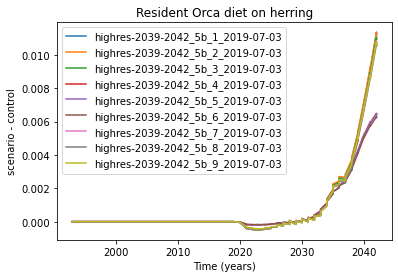

In [24]:
#plt.plot(control_ORR.Time/365, control_ORR.FCH, label='control')
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_ORR = scen[(scen['Predator'] == 'ORR')]
    diff = scen_ORR.FHE-control_ORR.FHE
    plt.plot(scen_ORR.Time/365+1992, diff, label = path.parent.stem)
plt.xlabel('Time (years)')
plt.ylabel('scenario - control')
plt.title('Resident Orca diet on herring')
plt.legend();

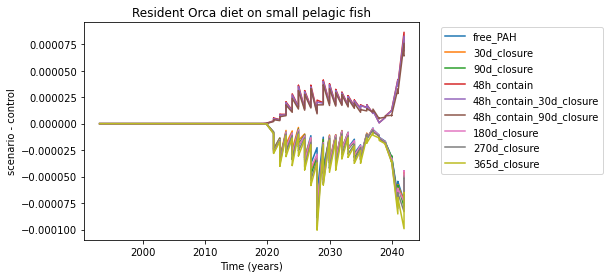

In [25]:
#plt.plot(control_ORR.Time/365, control_ORR.FCH, label='control')
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_ORR = scen[(scen['Predator'] == 'ORR')]
    diff = scen_ORR.FPS-control_ORR.FPS
    nm = str(path.parent.stem).split(sep='_')
    plt.plot(scen_ORR.Time/365+1992, diff, label = groups.scenarios[nm[2]])
plt.xlabel('Time (years)')
plt.ylabel('scenario - control')
plt.title('Resident Orca diet on small pelagic fish')
plt.legend(bbox_to_anchor=(1.05, 1),);

other salmonid diet

In [22]:
control_FSO = control[(control['Predator'] == 'FSO')]

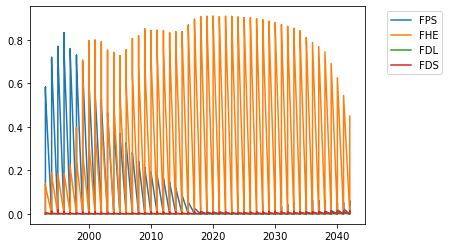

In [34]:
plt.plot(control_FSO.Time/365+1992,control_FSO.FPS,label='FPS')
plt.plot(control_FSO.Time/365+1992,control_FSO.FHE,label='FHE')
plt.plot(control_FSO.Time/365+1992,control_FSO.FDL,label='FDL')
plt.plot(control_FSO.Time/365+1992,control_FSO.FDS,label='FDS')
plt.legend(bbox_to_anchor=(1.05, 1),);

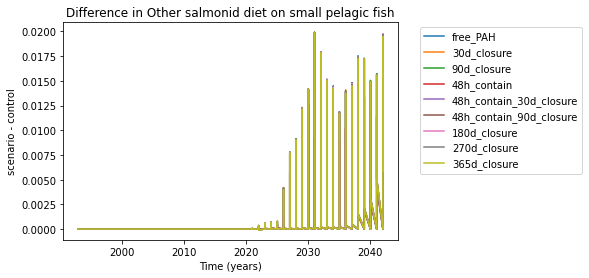

In [35]:
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_FSO = scen[(scen['Predator'] == 'FSO')]
    diff = scen_FSO.FPS-control_FSO.FPS
    nm = str(path.parent.stem).split(sep='_')
    plt.plot(scen_FSO.Time/365+1992, diff, label = groups.scenarios[nm[2]])
plt.xlabel('Time (years)')
plt.ylabel('scenario - control')
plt.title('Difference in Other salmonid diet on small pelagic fish')
plt.legend(bbox_to_anchor=(1.05, 1),);

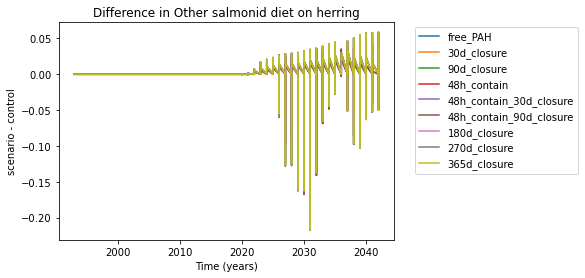

In [36]:
for scen, path in zip(scenario_datasets,scenario_paths):
    scen_FSO = scen[(scen['Predator'] == 'FSO')]
    diff = scen_FSO.FHE-control_FSO.FHE
    nm = str(path.parent.stem).split(sep='_')
    plt.plot(scen_FSO.Time/365+1992, diff, label = groups.scenarios[nm[2]])
plt.xlabel('Time (years)')
plt.ylabel('scenario - control')
plt.title('Difference in Other salmonid diet on herring')
plt.legend(bbox_to_anchor=(1.05, 1),);